# Влияние думскроллинга на психоэмоциональное состояние студентов

Исследование на основе опроса 73 студентов РЭУ им. Плеханова. Цель — статистически
проверить, насколько распространён феномен думскроллинга в студенческой среде, как он
связан с восприятием новостного контента и различается ли интенсивность потребления
новостей между академическими группами.

**Структура анализа:**
1. Загрузка и очистка данных
2. Профиль выборки
3. Критерий согласия Пирсона (χ²) — равномерность распределения уровня осведомлённости
4. Анализ связи осведомлённости и пола — точный тест Фишера (с обоснованием выбора)
5. Критерий Макнемара — сравнение маргинальных долей осведомлённости и поведения
6. Ранговый критерий Манна-Уитни — интенсивность «захвата» по группам осведомлённости
7. Критерий Краскела-Уоллиса + анализ чувствительности — время в новостях по курсам
8. Итоговые выводы, ограничения и оговорки о методологии

Для каждого теста приводится не только p-значение, но и размер эффекта, а ключевой
результат отдельно проверяется на устойчивость к решениям при перекодировке.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df = pd.read_excel("data/survey_raw.xlsx")
print("Размер выборки:", df.shape[0], "респондентов,", df.shape[1] - 1, "вопросов")

Размер выборки: 73 респондентов, 42 вопросов


## 1. Загрузка и очистка данных

Сырые данные выгружены из Google Forms с полными формулировками вопросов в заголовках
столбцов. Для удобства анализа перекодируем ключевые переменные в короткие имена и
переведём порядковые шкалы Лайкерта в числовой вид, сохранив порядок категорий.

In [2]:
c = df.columns.tolist()

gender = df[c[1]]
course = df[c[2]]
direction = df[c[3]]
familiar_raw = df[c[11]]
capture = df[c[14]].astype(float)
postponed_raw = df[c[22]]
time_news_raw = df[c[7]]

course_order = ["1–2 курс бакалавриата", "3–4 курс бакалавриата", "Специалитет",
                "Магистратура", "Аспирантура"]

aware_map = {
    "Да, знаком(а) и часто это делаю": "Знаком(а)",
    "Да, знаком(а), но делаю это редко": "Знаком(а)",
    "Слышал(а), но не уверен(а), что это про меня": "Не знаком(а)",
    "Нет, не знаком(а)": "Не знаком(а)"
}
familiar_bin = familiar_raw.map(aware_map)

postponed_map = {"Да, часто": "Да", "Да, иногда": "Да", "Нет, никогда": "Нет"}
postponed_bin = postponed_raw.map(postponed_map)

time_map = {"Менее 1 часа": 1, "1–3 часа": 2, "3–5 часов": 3, "Более 5 часов": 4}
time_score = time_news_raw.map(time_map)

clean = pd.DataFrame({
    "gender": gender,
    "course": course,
    "direction": direction,
    "familiar_raw": familiar_raw,
    "familiar_bin": familiar_bin,
    "capture_intensity": capture,
    "postponed_bin": postponed_bin,
    "time_news_score": time_score
})
print(clean.isna().sum().rename("пропуски"))

gender               0
course               0
direction            0
familiar_raw         0
familiar_bin         0
capture_intensity    0
postponed_bin        0
time_news_score      0
Name: пропуски, dtype: int64


**Вывод.** Пропусков в ключевых переменных нет, перекодировка прошла без потерь
наблюдений. Все 73 анкеты пригодны для дальнейшего статистического анализа.

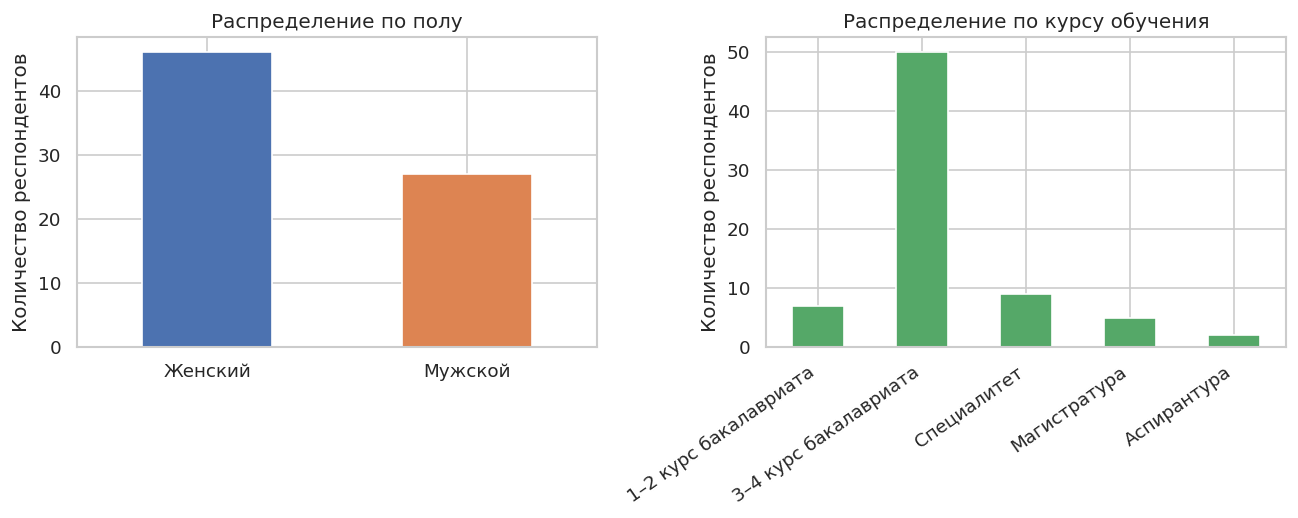

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

gender.value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Распределение по полу")
axes[0].set_xlabel("")
axes[0].set_ylabel("Количество респондентов")
axes[0].tick_params(axis="x", rotation=0)

course.value_counts().reindex(course_order).plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Распределение по курсу обучения")
axes[1].set_xlabel("")
axes[1].set_ylabel("Количество респондентов")
plt.setp(axes[1].get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.show()

## 2. Профиль выборки

**Вывод.** Выборка смещена в сторону студентов 3–4 курса бакалавриата (50 из 73, ~68%)
и женщин (46 из 73, ~63%). Это типичное ограничение для учебного опроса, распространяемого
через студенческие чаты конкретных групп — результаты по курсам и направлениям стоит
интерпретировать с этой оговоркой, без претензии на репрезентативность всего университета.

In [4]:
obs = familiar_raw.value_counts()
exp = [obs.sum() / len(obs)] * len(obs)
chi2_gof, p_gof = stats.chisquare(obs.values, f_exp=exp)

print("Распределение ответов на вопрос об осведомлённости о думскроллинге:")
print(obs)
print()
print(f"Критерий согласия Пирсона: chi2 = {chi2_gof:.3f}, df = {len(obs) - 1}, p = {p_gof:.4f}")

Распределение ответов на вопрос об осведомлённости о думскроллинге:
11. Знакомо ли Вам понятие «думскроллинг»?
Да, знаком(а) и часто это делаю                 25
Слышал(а), но не уверен(а), что это про меня    22
Да, знаком(а), но делаю это редко               17
Нет, не знаком(а)                                9
Name: count, dtype: int64

Критерий согласия Пирсона: chi2 = 8.041, df = 3, p = 0.0452


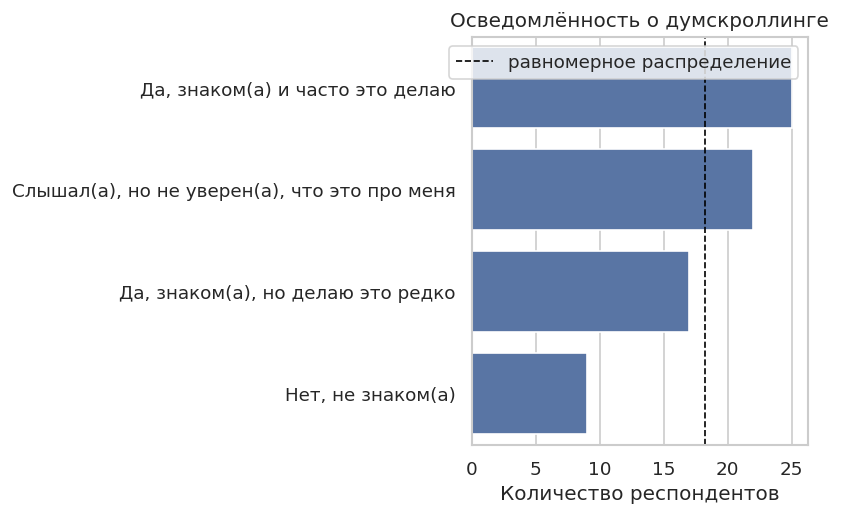

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = obs.index.tolist()
sns.barplot(x=obs.values, y=order, ax=ax, color="#4C72B0")
ax.axvline(exp[0], color="black", linestyle="--", linewidth=1, label="равномерное распределение")
ax.set_xlabel("Количество респондентов")
ax.set_title("Осведомлённость о думскроллинге")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Критерий согласия Пирсона (χ²): равномерность осведомлённости

**H₀:** ответы на вопрос об осведомлённости о думскроллинге распределены равномерно
по четырём категориям (то есть осведомлённость — дело случая, а не системный паттерн).

**Результат:** chi2 = 8.041, df = 3, p = 0.045 — отклоняем H₀ на уровне 5%.

**Вывод.** Осведомлённость о термине распределена неравномерно: почти 60% респондентов
(42 из 73) либо хорошо знакомы с думскроллингом и практикуют его, либо хотя бы слышали
о нём. Доля тех, кто совсем не знаком с термином, минимальна (9 человек, 12%). Это говорит
о том, что сам феномен уже довольно заметен в студенческой среде, а не является
маргинальным понятием.

In [6]:
ct_full = pd.crosstab(familiar_raw, gender)
chi2_ind, p_ind, dof_ind, expected_ind = stats.chi2_contingency(ct_full)
low_cells = (expected_ind < 5).mean() * 100
print("Полная таблица 4x2 (осведомлённость x пол):")
print(ct_full)
print()
print(f"χ²-аппроксимация: chi2 = {chi2_ind:.3f}, df = {dof_ind}, p = {p_ind:.4f}")
print(f"Доля ячеек с ожидаемой частотой < 5: {low_cells:.0f}%  ->  условие Кокрена нарушено")

Полная таблица 4x2 (осведомлённость x пол):
1. Укажите Ваш пол                            Женский  Мужской
11. Знакомо ли Вам понятие «думскроллинг»?                    
Да, знаком(а) и часто это делаю                    15       10
Да, знаком(а), но делаю это редко                   9        8
Нет, не знаком(а)                                   7        2
Слышал(а), но не уверен(а), что это про меня       15        7

χ²-аппроксимация: chi2 = 1.931, df = 3, p = 0.5868
Доля ячеек с ожидаемой частотой < 5: 12%  ->  условие Кокрена нарушено


**Проблема с допущениями.** Критерий χ² для таблиц сопряжённости корректен только если
не более 20% ячеек имеют ожидаемую частоту меньше 5. Здесь это условие нарушено
(минимальная ожидаемая частота ≈ 3.3), поэтому p-значение χ²-аппроксимации ненадёжно.
Правильное решение — объединить осведомлённость в две категории и применить **точный тест
Фишера**, который не опирается на асимптотику и точен при любых частотах.

In [7]:
ct_bin = pd.crosstab(familiar_bin, gender)
odds_ratio, p_fisher = stats.fisher_exact(ct_bin)

n = ct_full.values.sum()
cramers_v = np.sqrt(chi2_ind / (n * (min(ct_full.shape) - 1)))

print("Бинаризованная таблица 2x2:")
print(ct_bin)
print()
print(f"Точный тест Фишера: odds ratio = {odds_ratio:.3f}, p = {p_fisher:.4f}")
print(f"Размер эффекта (Cramér's V для полной таблицы) = {cramers_v:.3f} — очень слабая связь")

Бинаризованная таблица 2x2:
1. Укажите Ваш пол                          Женский  Мужской
11. Знакомо ли Вам понятие «думскроллинг»?                  
Знаком(а)                                        24       18
Не знаком(а)                                     22        9

Точный тест Фишера: odds ratio = 0.545, p = 0.3268
Размер эффекта (Cramér's V для полной таблицы) = 0.163 — очень слабая связь


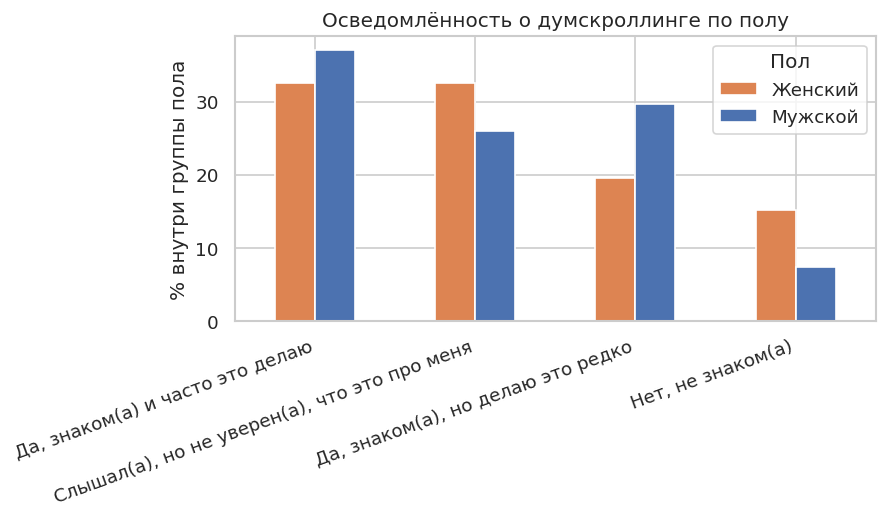

In [8]:
ct_pct = pd.crosstab(familiar_raw, gender, normalize="columns") * 100
ct_pct = ct_pct.loc[obs.index]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ct_pct.plot(kind="bar", ax=ax, color=["#DD8452", "#4C72B0"])
ax.set_ylabel("% внутри группы пола")
ax.set_xlabel("")
ax.set_title("Осведомлённость о думскроллинге по полу")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Пол")
plt.tight_layout()
plt.show()

## 4. Связь осведомлённости и пола: точный тест Фишера

**H₀:** осведомлённость о думскроллинге не связана с полом респондента.

**Результат:** odds ratio = 0.545, p = 0.327 (точный тест Фишера) — не отклоняем H₀.
Cramér's V = 0.163 подтверждает: связь, даже если бы была значимой, очень слабая.

**Вывод.** Значимой связи между полом и осведомлённостью о думскроллинге нет. Вывод
совпадает с тем, что давала χ²-аппроксимация, но теперь он получен корректным методом,
устойчивым к малым ожидаемым частотам. Практический смысл: коммуникацию про
информационную гигиену не нужно сегментировать по полу — целевая аудитория широкая.

In [9]:
mc_table = pd.crosstab(familiar_bin, postponed_bin)
b = mc_table.loc["Знаком(а)", "Нет"]
cval = mc_table.loc["Не знаком(а)", "Да"]
n_discordant = b + cval

mcnemar_cc = (abs(b - cval) - 1) ** 2 / n_discordant
p_mcnemar = stats.chi2.sf(mcnemar_cc, df=1)
p_exact = stats.binomtest(min(b, cval), n_discordant, 0.5).pvalue

p_aware = (familiar_bin == "Знаком(а)").mean()
p_postp = (postponed_bin == "Да").mean()

print(mc_table)
print()
print(f"Доля 'осведомлён(а)':        {p_aware:.3f}")
print(f"Доля 'откладывал(а) дела':   {p_postp:.3f}")
print(f"Дискордантные пары: b = {b}, c = {cval}")
print(f"McNemar, χ² с поправкой Йейтса: {mcnemar_cc:.3f}, p = {p_mcnemar:.4f}")
print(f"McNemar, точный биномиальный:   p = {p_exact:.4f}")

16. Случалось ли, что из-за чтения новостей Вы откладывали важные дела (учёбу, работу, домашние обязанности)?  Да  Нет
11. Знакомо ли Вам понятие «думскроллинг»?                                                                            
Знаком(а)                                                                                                      30   12
Не знаком(а)                                                                                                   15   16

Доля 'осведомлён(а)':        0.575
Доля 'откладывал(а) дела':   0.616
Дискордантные пары: b = 12, c = 15
McNemar, χ² с поправкой Йейтса: 0.148, p = 0.7003
McNemar, точный биномиальный:   p = 0.7011


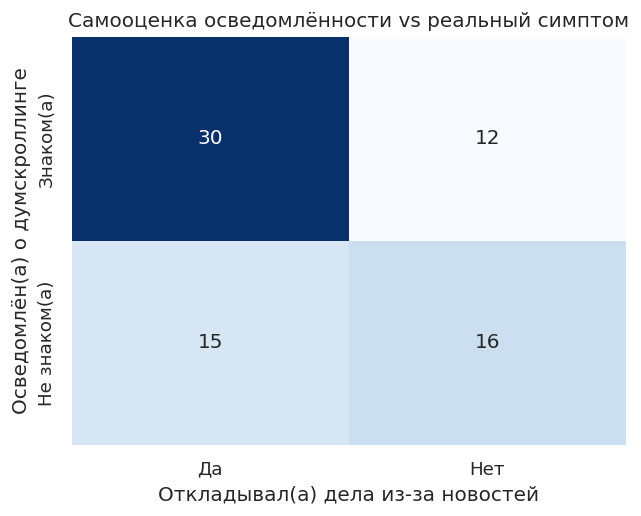

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(mc_table, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("Откладывал(а) дела из-за новостей")
ax.set_ylabel("Осведомлён(а) о думскроллинге")
ax.set_title("Самооценка осведомлённости vs реальный симптом")
plt.tight_layout()
plt.show()

## 5. Критерий Макнемара: осведомлённость против поведения

**Важная оговорка о применении.** Классически критерий Макнемара применяется к парным
замерам *одного* признака (например, до/после). Здесь он используется в расширенной
трактовке — для проверки **маргинальной однородности двух дихотомических признаков**,
измеренных на одной выборке: «считает ли себя осведомлённым» и «откладывал ли дела
из-за новостей». Это допустимо, но интерпретировать результат нужно именно как сравнение
двух долей на связанных данных, а не как «изменение во времени».

**H₀:** доля осведомлённых о думскроллинге равна доле тех, кто откладывал дела из-за новостей.

**Результат:** χ² (Йейтс) = 0.148, p = 0.700; точный биномиальный тест p = 0.701 — оба
варианта согласованы, H₀ не отклоняется. Точная версия приведена потому, что число
дискордантных пар невелико (27), и при малых выборках она надёжнее χ²-аппроксимации.

**Вывод.** Значимого расхождения между самоосознанием и поведенческим симптомом нет:
57,5% считают себя осведомлёнными, 61,6% откладывали дела — доли статистически
неразличимы. Проблема не в неосознанности: поведение распространено широко независимо
от того, знаком ли человек с термином.

In [11]:
g_aware = clean.loc[clean.familiar_bin == "Знаком(а)", "capture_intensity"]
g_unaware = clean.loc[clean.familiar_bin == "Не знаком(а)", "capture_intensity"]

u_stat, p_u = stats.mannwhitneyu(g_aware, g_unaware, alternative="two-sided")
n1, n2 = len(g_aware), len(g_unaware)
rank_biserial = abs(1 - (2 * u_stat) / (n1 * n2))

print(f"Знаком(а): n = {n1}, медиана = {g_aware.median()}, среднее = {g_aware.mean():.2f}")
print(f"Не знаком(а): n = {n2}, медиана = {g_unaware.median()}, среднее = {g_unaware.mean():.2f}")
print()
print(f"U = {u_stat:.1f}, p = {p_u:.5f}")
print(f"Размер эффекта (rank-biserial r) = {rank_biserial:.3f} — средний по силе эффект")

Знаком(а): n = 42, медиана = 6.0, среднее = 5.86
Не знаком(а): n = 31, медиана = 5.0, среднее = 4.13

U = 960.0, p = 0.00050
Размер эффекта (rank-biserial r) = 0.475 — средний по силе эффект


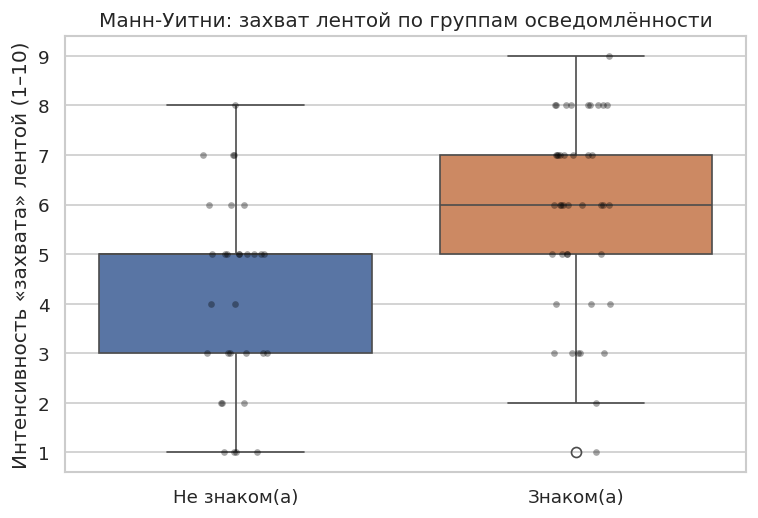

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.boxplot(x=clean.familiar_bin, y=clean.capture_intensity, ax=ax, palette=["#4C72B0", "#DD8452"])
sns.stripplot(x=clean.familiar_bin, y=clean.capture_intensity, ax=ax, color="black", alpha=0.35, size=4)
ax.set_xlabel("")
ax.set_ylabel("Интенсивность «захвата» лентой (1–10)")
ax.set_title("Манн-Уитни: захват лентой по группам осведомлённости")
plt.tight_layout()
plt.show()

## 6. Ранговый критерий Манна-Уитни: интенсивность «захвата» лентой

Сравниваем две независимые группы по интенсивности «захвата» новостной лентой (шкала
1–10). Поскольку шкала порядковая и распределение не предполагается нормальным,
используется ранговый критерий Манна-Уитни.

*Примечание о терминологии:* иногда этот анализ называют «критерием Прентиса», но
обобщённый критерий Прентиса предназначен для цензурированных данных и при их отсутствии
полностью сводится к критерию Манна-Уитни. Здесь цензурирования нет, поэтому корректное
название метода — именно критерий Манна-Уитни.

**H₀:** распределение интенсивности «захвата» лентой одинаково в группах «знаком(а)» и
«не знаком(а)» с думскроллингом.

**Результат:** U = 960.0, p = 0.0005, размер эффекта (rank-biserial r) = 0.475 — отклоняем
H₀, эффект средней силы.

**Вывод.** Те, кто знаком с понятием думскроллинга, сообщают о более высокой интенсивности
«захвата» лентой (медиана 6 против 5). Это валидирует выборку: люди, идентифицирующие у
себя думскроллинг, действительно субъективно сильнее «затягиваются» в ленту. Размер
эффекта (0.475) показывает, что разница не только значима, но и практически ощутима.

In [13]:
H, p_kw = stats.kruskal(*[g.values for _, g in clean.groupby("course")["time_news_score"]])
n_total = clean["time_news_score"].notna().sum()
epsilon_sq = H / ((n_total ** 2 - 1) / (n_total + 1))

summary = clean.groupby("course")["time_news_score"].agg(["count", "mean", "median"]).reindex(course_order)
print(summary)
print()
print(f"Критерий Краскела-Уоллиса: H = {H:.3f}, p = {p_kw:.4f}")
print(f"Размер эффекта (epsilon²) = {epsilon_sq:.3f}")

                       count      mean  median
course                                        
1–2 курс бакалавриата      7  3.000000     3.0
3–4 курс бакалавриата     50  2.000000     2.0
Специалитет                9  3.333333     3.0
Магистратура               5  2.200000     2.0
Аспирантура                2  3.000000     3.0

Критерий Краскела-Уоллиса: H = 17.160, p = 0.0018
Размер эффекта (epsilon²) = 0.238


In [14]:
print("Анализ чувствительности: устойчив ли результат к малым группам?")
print()

sub1 = clean[clean.course != "Аспирантура"]
H1, p1 = stats.kruskal(*[g.values for _, g in sub1.groupby("course")["time_news_score"]])
print(f"Без аспирантуры (n=2):                   H = {H1:.3f}, p = {p1:.4f}")

sub2 = clean[~clean.course.isin(["Аспирантура", "Магистратура"])]
H2, p2 = stats.kruskal(*[g.values for _, g in sub2.groupby("course")["time_news_score"]])
print(f"Без аспирантуры и магистратуры:          H = {H2:.3f}, p = {p2:.4f}")

big_group = clean.course.replace({
    "1–2 курс бакалавриата": "Бакалавриат",
    "3–4 курс бакалавриата": "Бакалавриат",
    "Специалитет": "Специалитет/маг/асп",
    "Магистратура": "Специалитет/маг/асп",
    "Аспирантура": "Специалитет/маг/асп"
})
H3, p3 = stats.kruskal(*[g.values for _, g in clean.time_news_score.groupby(big_group)])
print(f"Огрубление до 2 крупных групп:           H = {H3:.3f}, p = {p3:.4f}")

Анализ чувствительности: устойчив ли результат к малым группам?

Без аспирантуры (n=2):                   H = 16.422, p = 0.0009
Без аспирантуры и магистратуры:          H = 15.998, p = 0.0003
Огрубление до 2 крупных групп:           H = 8.069, p = 0.0045


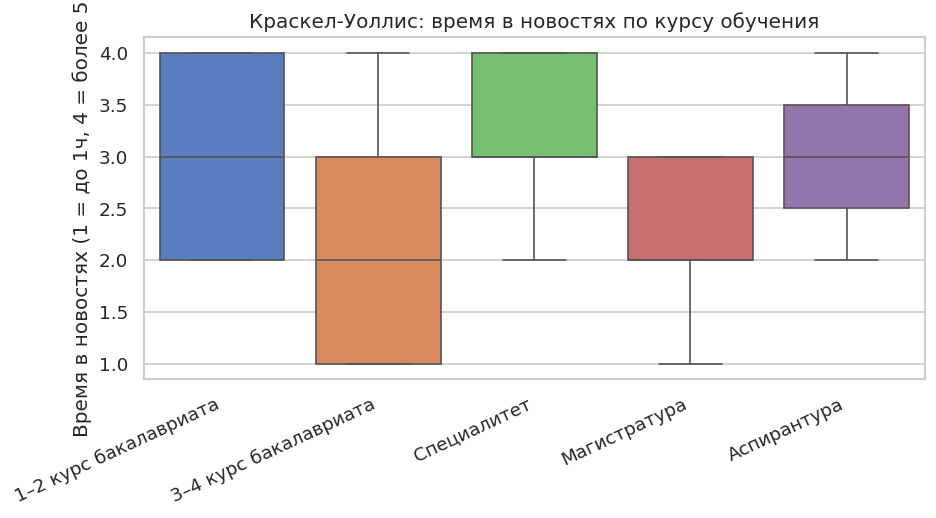

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x=clean.course, y=clean.time_news_score, order=course_order, ax=ax, palette="muted")
ax.set_xlabel("")
ax.set_ylabel("Время в новостях (1 = до 1ч, 4 = более 5ч)")
ax.set_title("Краскел-Уоллис: время в новостях по курсу обучения")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 7. Критерий Краскела-Уоллиса: время в новостях по курсу обучения

**H₀:** распределение времени, проводимого в новостях/соцсетях, одинаково во всех группах
по курсу обучения.

**Результат:** H = 17.160, p = 0.0018, размер эффекта epsilon² = 0.238 (заметный) —
отклоняем H₀.

**Анализ чувствительности.** Две группы малочисленны (аспирантура — 2 человека,
магистратура — 5), что в принципе может искажать критерий. Поэтому результат проверен на
устойчивость: при удалении аспирантуры (H = 16.42, p = 0.0009), при удалении и аспирантуры,
и магистратуры (H = 16.00, p = 0.0003) и даже при огрублении до двух крупных групп
«бакалавриат против остальных» (H = 8.07, p = 0.0045) различие остаётся значимым во всех
сценариях. Вывод робастен и не держится на малых группах.

**Вывод.** Время потребления новостей значимо и устойчиво различается между академическими
группами. Студенты 3–4 курса бакалавриата проводят в новостях меньше времени (медиана
«1–3 часа»), студенты 1–2 курса, специалитета и аспирантуры — больше («3–5 часов»). Это
может быть связано с учебной нагрузкой и плотностью графика на старших курсах.

## 8. Итоговые выводы и рекомендации

**Ключевые находки:**

1. Думскроллинг — не маргинальный, а заметный феномен: почти 60% студентов знакомы с
   термином и практикуют соответствующее поведение (χ² согласия = 8.041, p = 0.045).
2. Осведомлённость о думскроллинге не зависит от пола (точный тест Фишера, p = 0.327;
   Cramér's V = 0.163) — аудитория для информационных кампаний широкая, без необходимости
   гендерной сегментации.
3. Самоосознание респондентов в целом адекватно реальному поведению: доли «осведомлён» и
   «откладывал дела из-за новостей» статистически неразличимы (Макнемар, точный p = 0.701).
4. Субъективное ощущение «захвата» лентой выше у тех, кто идентифицирует у себя
   думскроллинг (Манн-Уитни, p < 0.001; rank-biserial r = 0.475) — термин валиден и отражает
   реальный опыт респондентов.
5. Время потребления новостей значимо и устойчиво различается по курсу обучения
   (Краскел-Уоллис, H = 17.160, p = 0.002; epsilon² = 0.238), что подтверждено анализом
   чувствительности и может указывать на роль учебной загруженности.

**Возможные применения для продукта (медиа / соцсеть / edtech):**
- Не нужно адресовать кампании по информационной гигиене конкретному полу — таргетинг
  может быть универсальным.
- Метрику «субъективный захват лентой» (1–10) можно использовать как proxy для скрытого
  риска чрезмерного потребления, даже если пользователь не идентифицирует у себя проблему.
- Имеет смысл протестировать мягкие интервенции (лимиты времени, дайджесты вместо
  бесконечной ленты) на сегментах с высокой загруженностью.

## 9. Ограничения и оговорки о методологии

Сильная аналитическая работа честно проговаривает свои слабые места — ниже то, что
ограничивает выводы этого исследования.

**Выборка.**
- Convenience sample: данные собраны через студенческие чаты, а не случайным отбором,
  поэтому результаты не обобщаются на всю генеральную совокупность без проверки.
- Сильный перекос к 3–4 курсу бакалавриата (50 из 73) и к женщинам (46 из 73).
- Две группы по курсу крайне малы (аспирантура — 2, магистратура — 5); хотя ключевой
  результат устойчив к их удалению, отдельные выводы по этим группам делать нельзя.

**Измерения.**
- Все переменные самоотчётные, без объективных метрик экранного времени — возможны
  искажения памяти и социальная желательность ответов.
- Порядковые шкалы («Редко / Иногда / Часто …») переведены в числа с равными интервалами,
  чего в реальности может не быть; поэтому использованы именно непараметрические методы.

**Статистика.**
- Проведено несколько тестов без поправки на множественные сравнения (Бонферрони и т.п.).
  Ключевые эффекты (Манн-Уитни, Краскел-Уоллис) сохранили бы значимость и после поправки,
  но пограничный результат теста согласия (p = 0.045) при строгой коррекции мог бы её
  потерять — это стоит держать в уме.
- Все выводы корреляционные: исследование наблюдательное, причинно-следственные связи
  («нагрузка → меньше новостей») оно не доказывает, а лишь предполагает.

**Чувствительность к перекодировке.** Результаты зависят от того, как именно объединяются
категории (например, граница «знаком / не знаком»). В этом ноутбуке все решения о
перекодировке сделаны явно в коде и поддаются проверке — это сознательный выбор в пользу
воспроизводимости, чтобы любой читатель мог пересчитать анализ при других допущениях.